# Implementação de TCN para Previsão de
Implementação de TCN para Previsão de Curvas de Carga
Este notebook implementa uma Rede Neural Convolucional Temporal (TCN) para previsão de curvas de carga de energia elétrica, seguindo o estilo didático do livro "Dive into Deep Learning" (D2L).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import math
from datetime import datetime, timedelta
import seaborn as sns
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# Configuração para gráficos mais bonitos
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (14, 6)

In [10]:
# Carregar os dados
df = pd.read_csv('dados.csv', sep=';')

# Visualizar primeiras linhas
print("Primeiras linhas dos dados:")
print(df.head())

# Informações básicas
print("\nInformações do DataFrame:")
print(df.info())

# Estatísticas descritivas
print("\nEstatísticas descritivas:")
print(df.describe())

Primeiras linhas dos dados:
          din_instante id_subsistema_origem nom_subsistema_origem  \
0  2025-01-01 00:00:00                    N                 NORTE   
1  2025-01-01 00:00:00                    N                 NORTE   
2  2025-01-01 00:00:00                   NE              NORDESTE   
3  2025-01-01 00:00:00                   SE               SUDESTE   
4  2025-01-01 01:00:00                    N                 NORTE   

  id_subsistema_destino nom_subsistema_destino  val_intercambiomwmed  
0                    NE               NORDESTE             -1606.789  
1                    SE                SUDESTE              3305.342  
2                    SE                SUDESTE              4847.116  
3                     S                    SUL              1096.231  
4                    NE               NORDESTE             -1558.713  

Informações do DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23328 entries, 0 to 23327
Data columns (total 6 column

In [12]:
# Converter coluna de timestamp para datetime
df['din_instante'] = pd.to_datetime(df['din_instante'])

# Ordenar por timestamp
df = df.sort_values('din_instante')

# Verificar intervalo de tempo e dados faltantes
print(f"Período dos dados: {df['din_instante'].min()} até {df['din_instante'].max()}")
print(f"Intervalo esperado: {(df['din_instante'].max() - df['din_instante'].min()).total_seconds() / 3600 + 1} horas")
print(f"Número de registros: {len(df)}")

# Verificar frequência e valores ausentes
timedeltas = df['din_instante'].diff().value_counts()
print("\nDistribuição de intervalos entre registros:")
print(timedeltas)

Período dos dados: 2025-01-01 00:00:00 até 2025-08-31 23:00:00
Intervalo esperado: 5832.0 horas
Número de registros: 23328

Distribuição de intervalos entre registros:
din_instante
0 days 00:00:00    17496
0 days 01:00:00     5831
Name: count, dtype: int64


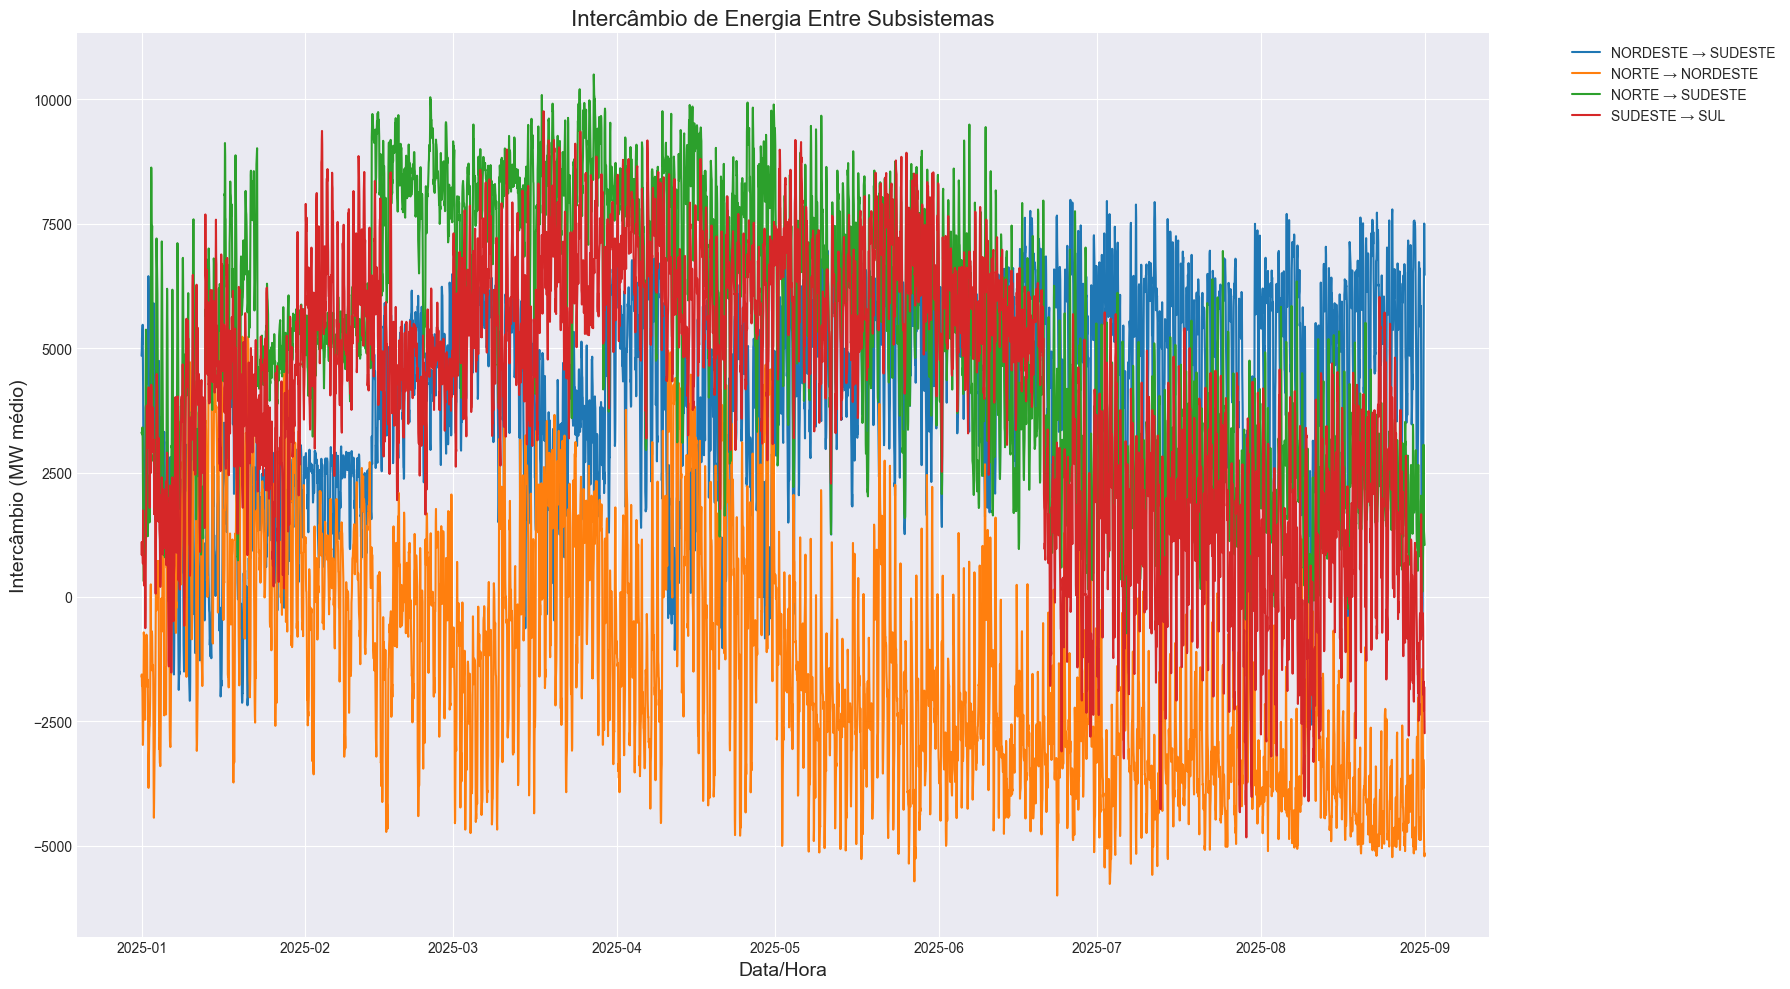

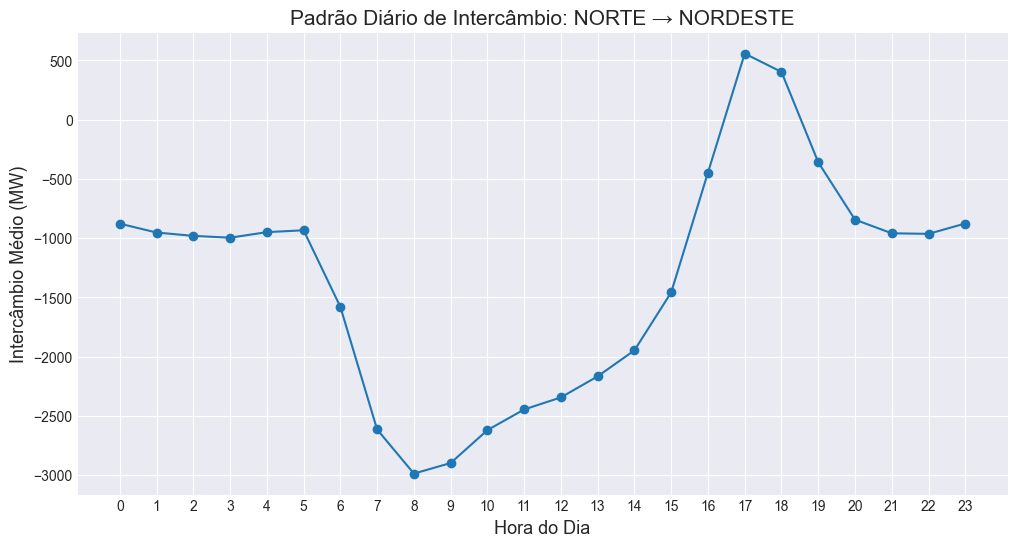

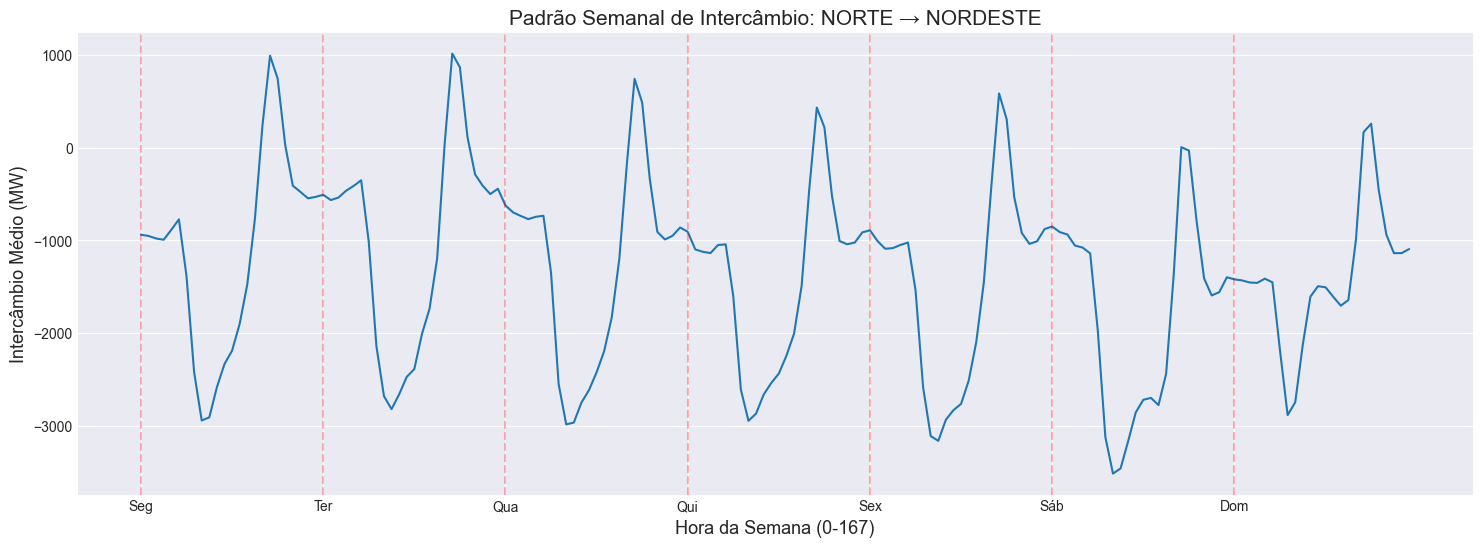

In [13]:
# Preparar um DataFrame pivotado para visualização por fluxo de origem-destino
pivot_df = df.pivot_table(
    index='din_instante', 
    columns=['nom_subsistema_origem', 'nom_subsistema_destino'], 
    values='val_intercambiomwmed'
)

# Gráfico de série temporal
plt.figure(figsize=(18, 10))
for col in pivot_df.columns:
    plt.plot(pivot_df.index, pivot_df[col], label=f"{col[0]} → {col[1]}")
plt.title('Intercâmbio de Energia Entre Subsistemas', fontsize=16)
plt.xlabel('Data/Hora', fontsize=14)
plt.ylabel('Intercâmbio (MW médio)', fontsize=14)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Analisar padrões diários (24h)
def plot_daily_pattern(df, origem, destino):
    subset = df[(df['nom_subsistema_origem'] == origem) & 
                (df['nom_subsistema_destino'] == destino)]
    
    subset['hour'] = subset['din_instante'].dt.hour
    daily_pattern = subset.groupby('hour')['val_intercambiomwmed'].mean()
    
    plt.figure(figsize=(12, 6))
    plt.plot(daily_pattern.index, daily_pattern.values, marker='o', linestyle='-')
    plt.title(f'Padrão Diário de Intercâmbio: {origem} → {destino}', fontsize=15)
    plt.xlabel('Hora do Dia', fontsize=13)
    plt.ylabel('Intercâmbio Médio (MW)', fontsize=13)
    plt.grid(True)
    plt.xticks(range(0, 24))
    plt.show()

# Escolher um par origem-destino para análise
origem = 'NORTE'
destino = 'NORDESTE'
plot_daily_pattern(df, origem, destino)

# Padrão semanal (168h)
def plot_weekly_pattern(df, origem, destino):
    subset = df[(df['nom_subsistema_origem'] == origem) & 
                (df['nom_subsistema_destino'] == destino)]
    
    subset['dayofweek'] = subset['din_instante'].dt.dayofweek
    subset['hour'] = subset['din_instante'].dt.hour
    subset['hourofweek'] = subset['dayofweek'] * 24 + subset['hour']
    
    weekly_pattern = subset.groupby('hourofweek')['val_intercambiomwmed'].mean()
    
    plt.figure(figsize=(18, 6))
    plt.plot(weekly_pattern.index, weekly_pattern.values)
    plt.title(f'Padrão Semanal de Intercâmbio: {origem} → {destino}', fontsize=15)
    plt.xlabel('Hora da Semana (0-167)', fontsize=13)
    plt.ylabel('Intercâmbio Médio (MW)', fontsize=13)
    plt.grid(True)
    days = ['Seg', 'Ter', 'Qua', 'Qui', 'Sex', 'Sáb', 'Dom']
    plt.xticks([i*24 for i in range(7)], days)
    for i in range(7):
        plt.axvline(x=i*24, color='r', linestyle='--', alpha=0.3)
    plt.show()

plot_weekly_pattern(df, origem, destino)

Número de timestamps faltantes: 0


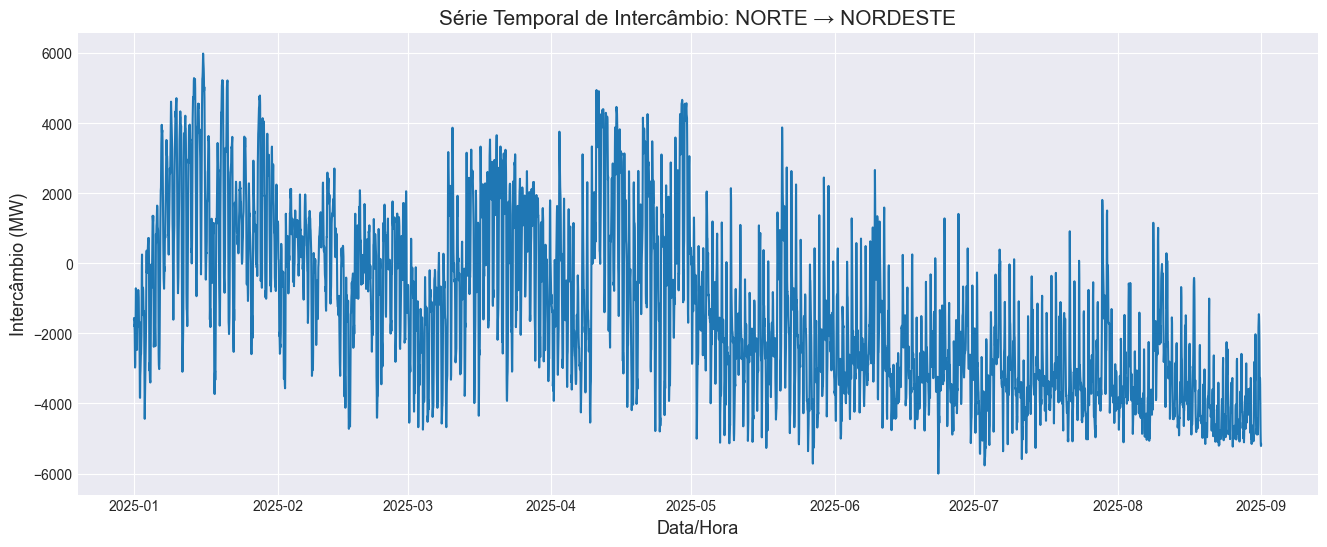

In [14]:
# Selecionar um par origem-destino específico para o modelo
origem_destino = (origem, destino)
target_df = df[(df['nom_subsistema_origem'] == origem_destino[0]) & 
               (df['nom_subsistema_destino'] == origem_destino[1])]

# Reorganizar para formato de série temporal
ts_df = target_df.set_index('din_instante')[['val_intercambiomwmed']].copy()
ts_df.columns = ['MW']

# Verificar se temos lacunas na série temporal
missing_times = pd.date_range(start=ts_df.index.min(), end=ts_df.index.max(), freq='1H').difference(ts_df.index)
print(f"Número de timestamps faltantes: {len(missing_times)}")

# Preencher quaisquer lacunas com interpolação linear
if len(missing_times) > 0:
    ts_df = ts_df.reindex(pd.date_range(start=ts_df.index.min(), end=ts_df.index.max(), freq='1H'))
    ts_df = ts_df.interpolate(method='linear')

# Visualizar a série temporal resultante
plt.figure(figsize=(16, 6))
plt.plot(ts_df.index, ts_df['MW'])
plt.title(f'Série Temporal de Intercâmbio: {origem} → {destino}', fontsize=15)
plt.xlabel('Data/Hora', fontsize=13)
plt.ylabel('Intercâmbio (MW)', fontsize=13)
plt.grid(True)
plt.show()

In [15]:
def add_calendar_features(df):
    """
    Adiciona features de calendário ao DataFrame.
    
    Args:
        df: DataFrame com índice datetime
        
    Returns:
        DataFrame com features de calendário adicionadas
    """
    df = df.copy()
    
    # Features básicas de tempo
    df['hour'] = df.index.hour
    df['dayofweek'] = df.index.dayofweek
    df['month'] = df.index.month
    df['day'] = df.index.day
    df['year'] = df.index.year
    
    # Encoding cíclico
    df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
    df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)
    
    df['day_sin'] = np.sin(2 * np.pi * df['day'] / 31)
    df['day_cos'] = np.cos(2 * np.pi * df['day'] / 31)
    
    df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
    df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)
    
    df['dayofweek_sin'] = np.sin(2 * np.pi * df['dayofweek'] / 7)
    df['dayofweek_cos'] = np.cos(2 * np.pi * df['dayofweek'] / 7)
    
    # Identificadores de períodos especiais
    df['is_weekend'] = df['dayofweek'].isin([5, 6]).astype(int)
    
    # Simplificação: como não temos uma lista de feriados,
    # vamos apenas fingir que os fins de semana são feriados
    df['is_holiday'] = df['is_weekend']
    
    # Lags importantes (t-24 e t-168)
    df['MW_lag24'] = df['MW'].shift(24)
    df['MW_lag168'] = df['MW'].shift(168)
    
    return df

# Aplicar features de calendário
ts_df_features = add_calendar_features(ts_df)
print("DataFrame com features de calendário:")
print(ts_df_features.head())

DataFrame com features de calendário:
                           MW  hour  dayofweek  month  day  year  hour_sin  \
din_instante                                                                 
2025-01-01 00:00:00 -1606.789     0          2      1    1  2025  0.000000   
2025-01-01 01:00:00 -1558.713     1          2      1    1  2025  0.258819   
2025-01-01 02:00:00 -1791.762     2          2      1    1  2025  0.500000   
2025-01-01 03:00:00 -1750.137     3          2      1    1  2025  0.707107   
2025-01-01 04:00:00 -1921.347     4          2      1    1  2025  0.866025   

                     hour_cos   day_sin  day_cos  month_sin  month_cos  \
din_instante                                                             
2025-01-01 00:00:00  1.000000  0.201299  0.97953        0.5   0.866025   
2025-01-01 01:00:00  0.965926  0.201299  0.97953        0.5   0.866025   
2025-01-01 02:00:00  0.866025  0.201299  0.97953        0.5   0.866025   
2025-01-01 03:00:00  0.707107  0.201299  0.97

In [16]:
class Scaler:
    """
    Classe para normalização de dados, mantendo separadamente
    o ajuste (fit) e a aplicação (transform).
    """
    def __init__(self):
        self.scaler = StandardScaler()
        self.fitted = False
        
    def fit(self, df):
        """
        Ajusta o scaler nos dados.
        
        Args:
            df: DataFrame a ser usado para ajuste
        """
        self.scaler.fit(df)
        self.fitted = True
        
    def transform(self, df):
        """
        Aplica a transformação nos dados.
        
        Args:
            df: DataFrame a ser transformado
            
        Returns:
            DataFrame normalizado
        """
        if not self.fitted:
            raise ValueError("O scaler precisa ser ajustado antes de transformar")
        return pd.DataFrame(
            self.scaler.transform(df),
            index=df.index,
            columns=df.columns
        )
    
    def inverse_transform(self, df):
        """
        Reverte a transformação.
        
        Args:
            df: DataFrame normalizado
            
        Returns:
            DataFrame na escala original
        """
        if not self.fitted:
            raise ValueError("O scaler precisa ser ajustado antes de inverter a transformação")
        return pd.DataFrame(
            self.scaler.inverse_transform(df),
            index=df.index,
            columns=df.columns
        )

# Função para separar features e target
def prepare_features_target(df):
    """
    Separa o DataFrame em features e target.
    
    Args:
        df: DataFrame com todas as colunas
        
    Returns:
        Tuple (X, y) com DataFrames de features e target
    """
    target_col = ['MW']
    
    # Removemos os lags NaN
    df = df.dropna()
    
    # Removemos colunas categóricas originais e mantemos apenas as transformadas
    feature_cols = [col for col in df.columns if col not in target_col and col not in ['hour', 'dayofweek', 'day', 'month', 'year']]
    
    return df[feature_cols], df[target_col]

In [17]:
def temporal_split(df, train_ratio=0.7, val_ratio=0.15):
    """
    Divide os dados em conjuntos de treino, validação e teste respeitando a ordem temporal.
    
    Args:
        df: DataFrame com índice de tempo
        train_ratio: Proporção dos dados para treino
        val_ratio: Proporção dos dados para validação
        
    Returns:
        Tuple (train_range, val_range, test_range) com intervalos de índices
    """
    # Ordena por índice de tempo
    df = df.sort_index()
    
    # Calcula os pontos de corte
    n = len(df)
    train_end = int(n * train_ratio)
    val_end = int(n * (train_ratio + val_ratio))
    
    # Define os ranges temporais
    train_range = (df.index[0], df.index[train_end-1])
    val_range = (df.index[train_end], df.index[val_end-1])
    test_range = (df.index[val_end], df.index[-1])
    
    print(f"Treino: {train_range[0]} até {train_range[1]} ({train_end} amostras)")
    print(f"Validação: {val_range[0]} até {val_range[1]} ({val_end - train_end} amostras)")
    print(f"Teste: {test_range[0]} até {test_range[1]} ({n - val_end} amostras)")
    
    return train_range, val_range, test_range

# Obter os intervalos para cada conjunto
X_df, y_df = prepare_features_target(ts_df_features)
train_range, val_range, test_range = temporal_split(X_df)

# Separar os conjuntos
train_X = X_df.loc[train_range[0]:train_range[1]]
val_X = X_df.loc[val_range[0]:val_range[1]]
test_X = X_df.loc[test_range[0]:test_range[1]]

train_y = y_df.loc[train_range[0]:train_range[1]]
val_y = y_df.loc[val_range[0]:val_range[1]]
test_y = y_df.loc[test_range[0]:test_range[1]]

# Normalizar os dados
X_scaler = Scaler()
X_scaler.fit(train_X)

train_X_scaled = X_scaler.transform(train_X)
val_X_scaled = X_scaler.transform(val_X)
test_X_scaled = X_scaler.transform(test_X)

y_scaler = Scaler()
y_scaler.fit(train_y)

train_y_scaled = y_scaler.transform(train_y)
val_y_scaled = y_scaler.transform(val_y)
test_y_scaled = y_scaler.transform(test_y)

Treino: 2025-01-08 00:00:00 até 2025-06-22 03:00:00 (3964 amostras)
Validação: 2025-06-22 04:00:00 até 2025-07-27 13:00:00 (850 amostras)
Teste: 2025-07-27 14:00:00 até 2025-08-31 23:00:00 (850 amostras)


In [18]:
class TimeSeriesDataset(Dataset):
    """
    Dataset para séries temporais com janelamento deslizante.
    """
    def __init__(self, X, y, window_size, horizon, stride=1):
        """
        Inicializa o dataset.
        
        Args:
            X: DataFrame ou array com features
            y: DataFrame ou array com target
            window_size: Tamanho da janela de contexto (W)
            horizon: Horizonte de previsão (H)
            stride: Passo entre amostras consecutivas
        """
        self.X = X.values if hasattr(X, 'values') else X
        self.y = y.values if hasattr(y, 'values') else y
        self.window_size = window_size
        self.horizon = horizon
        self.stride = stride
        self.n_samples = max(0, (len(self.X) - window_size - horizon + 1) // stride)
        
    def __len__(self):
        return self.n_samples
    
    def __getitem__(self, idx):
        # Calcula o início da janela
        start_idx = idx * self.stride
        end_idx = start_idx + self.window_size
        
        # Extrai a janela de contexto
        X_window = self.X[start_idx:end_idx]
        
        # Extrai o target (um passo ou multi-passos)
        if self.horizon == 1:
            y_target = self.y[end_idx]
        else:
            y_target = self.y[end_idx:end_idx + self.horizon].reshape(-1)
            
        return torch.FloatTensor(X_window), torch.FloatTensor(y_target)

def create_dataloaders(train_X, train_y, val_X, val_y, test_X, test_y, 
                       window_size, horizon, batch_size, stride=1):
    """
    Cria dataloaders para treino, validação e teste.
    
    Args:
        train_X, train_y, val_X, val_y, test_X, test_y: Dados separados
        window_size: Tamanho da janela de contexto
        horizon: Horizonte de previsão
        batch_size: Tamanho do batch
        stride: Passo entre amostras consecutivas
        
    Returns:
        Dataloaders para treino, validação e teste
    """
    train_dataset = TimeSeriesDataset(train_X, train_y, window_size, horizon, stride)
    val_dataset = TimeSeriesDataset(val_X, val_y, window_size, horizon, stride)
    test_dataset = TimeSeriesDataset(test_X, test_y, window_size, horizon, stride)
    
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    # Não embaralhamos validação e teste para preservar a ordem temporal
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
    
    print(f"Criados dataloaders com {len(train_dataset)} amostras de treino, "
          f"{len(val_dataset)} de validação e {len(test_dataset)} de teste.")
    
    return train_loader, val_loader, test_loader

# Criar os dataloaders
window_size = 720  # 30 dias * 24 horas
horizon = 24  # Previsão para as próximas 24 horas
batch_size = 32
stride = 1

train_loader, val_loader, test_loader = create_dataloaders(
    train_X_scaled, train_y_scaled, 
    val_X_scaled, val_y_scaled,
    test_X_scaled, test_y_scaled,
    window_size, horizon, batch_size, stride
)

# Verificar formato dos dados
for X_batch, y_batch in train_loader:
    print(f"X batch shape: {X_batch.shape}")  # [batch, window_size, n_features]
    print(f"y batch shape: {y_batch.shape}")  # [batch, horizon]
    break

Criados dataloaders com 3221 amostras de treino, 107 de validação e 107 de teste.
X batch shape: torch.Size([32, 720, 12])
y batch shape: torch.Size([32, 24])


In [19]:
class Animator:
    """
    Classe para animação de gráficos durante o treinamento, similar ao D2L.
    """
    def __init__(self, xlabel=None, ylabel=None, legend=None, xlim=None,
                 ylim=None, title=None, figsize=(12, 4)):
        self.fig, self.ax = plt.subplots(figsize=figsize)
        self.xlabel = xlabel
        self.ylabel = ylabel
        self.xlim = xlim
        self.ylim = ylim
        self.title = title
        self.legend = legend
        self.X = []
        self.Y = []
        self.lines = []
        
        if xlabel:
            self.ax.set_xlabel(xlabel)
        if ylabel:
            self.ax.set_ylabel(ylabel)
        if xlim:
            self.ax.set_xlim(xlim)
        if ylim:
            self.ax.set_ylim(ylim)
        if title:
            self.ax.set_title(title)
            
    def add(self, x, y):
        # Se x e y são escalares, os transformamos em listas
        if not hasattr(y, "__len__"):
            y = [y]
        if not hasattr(x, "__len__"):
            x = [x] * len(y)
            
        if len(self.X) == 0:
            self.X = [[] for _ in range(len(y))]
            self.Y = [[] for _ in range(len(y))]
            # Inicializa as linhas no primeiro uso
            for i in range(len(y)):
                line, = self.ax.plot([], [], label=self.legend[i] if self.legend else None)
                self.lines.append(line)
                
        for i, (xi, yi) in enumerate(zip(x, y)):
            self.X[i].append(xi)
            self.Y[i].append(yi)
            self.lines[i].set_data(self.X[i], self.Y[i])
            
        # Ajusta os limites do gráfico se necessário
        self.ax.relim()
        self.ax.autoscale_view()
        
        if self.legend:
            self.ax.legend(loc='best')
            
        # Atualiza o gráfico
        self.fig.canvas.draw()
        plt.pause(0.1)
        
    def save(self, path):
        self.fig.savefig(path)

def calculate_metrics(y_true, y_pred):
    """
    Calcula métricas comuns para avaliação de previsões.
    
    Args:
        y_true: Array com valores reais
        y_pred: Array com valores previstos
        
    Returns:
        Dict com métricas calculadas
    """
    mae = np.mean(np.abs(y_true - y_pred))
    rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))
    
    # sMAPE (symmetric Mean Absolute Percentage Error)
    smape = 100 * np.mean(2 * np.abs(y_pred - y_true) / (np.abs(y_pred) + np.abs(y_true)))
    
    return {
        'mae': mae,
        'rmse': rmse,
        'smape': smape
    }

def baseline_seasonal_prediction(y, horizon, seasonal_period=24):
    """
    Cria uma previsão baseline baseada na sazonalidade.
    
    Args:
        y: Array com valores históricos
        horizon: Horizonte de previsão
        seasonal_period: Período sazonal (24 para diário, 168 para semanal)
        
    Returns:
        Array com previsões baseline
    """
    # Verificamos se temos dados suficientes
    if len(y) < seasonal_period:
        raise ValueError(f"Precisamos de pelo menos {seasonal_period} pontos para a previsão sazonal")
    
    predictions = []
    for i in range(horizon):
        # Para cada horizonte, pegamos o valor correspondente do último período
        predictions.append(y[-(seasonal_period - i % seasonal_period)])
        
    return np.array(predictions)

In [20]:
class ResidualBlock(nn.Module):
    """
    Bloco residual para TCN.
    """
    def __init__(self, in_channels, out_channels, kernel_size, dilation, dropout=0.2):
        super(ResidualBlock, self).__init__()
        
        # Padding causal para preservar a causalidade temporal
        self.padding = (kernel_size - 1) * dilation
        
        # Primeira camada convolucional
        self.conv1 = nn.Conv1d(
            in_channels, 
            out_channels,
            kernel_size,
            padding=self.padding,
            dilation=dilation
        )
        self.bn1 = nn.BatchNorm1d(out_channels)
        self.dropout1 = nn.Dropout(dropout)
        
        # Segunda camada convolucional
        self.conv2 = nn.Conv1d(
            out_channels,
            out_channels,
            kernel_size,
            padding=self.padding,
            dilation=dilation
        )
        self.bn2 = nn.BatchNorm1d(out_channels)
        self.dropout2 = nn.Dropout(dropout)
        
        # Conexão residual (skip connection)
        self.downsample = nn.Conv1d(in_channels, out_channels, 1) if in_channels != out_channels else None
        self.relu = nn.ReLU()
        
    def forward(self, x):
        # Entrada original para a conexão residual
        residual = x
        
        # Primeira camada convolucional
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)
        out = self.dropout1(out)
        
        # Segunda camada convolucional
        out = self.conv2(out)
        out = self.bn2(out)
        out = self.dropout2(out)
        
        # Ajusta a dimensão da entrada original se necessário
        if self.downsample is not None:
            residual = self.downsample(residual)
            
        # Soma com a conexão residual
        out = out[:, :, :residual.size(2)] + residual  # Corta o padding extra
        out = self.relu(out)
        
        return out

In [22]:
class TCN(nn.Module):
    """
    Temporal Convolutional Network
    """
    def __init__(self, input_size, output_size, num_channels, kernel_size, 
                 dropout=0.2, num_levels=8):
        super(TCN, self).__init__()
        
        layers = []
        in_channels = input_size
        
        # Empilhamento de blocos residuais com dilatação exponencial
        for i in range(num_levels):
            dilation = 2 ** i
            out_channels = num_channels
            layers.append(ResidualBlock(in_channels, out_channels, kernel_size, dilation, dropout))
            in_channels = out_channels
            
        self.network = nn.Sequential(*layers)
        
        # Camada de saída
        self.output_layer = nn.Sequential(
            nn.AdaptiveAvgPool1d(1),
            nn.Flatten(),
            nn.Linear(num_channels, output_size)
        )
        
        # Inicialização dos pesos
        self._init_weights()
        
    def _init_weights(self):
        """
        Inicializa os pesos da rede usando inicialização de Kaiming.
        """
        for m in self.modules():
            if isinstance(m, nn.Conv1d) or isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, mode='fan_in', nonlinearity='relu')
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
                    
    def forward(self, x):
        """
        Args:
            x: Tensor de entrada [batch_size, seq_len, input_size]
            
        Returns:
            Tensor de saída [batch_size, output_size]
        """
        # Troca as dimensões para [batch_size, input_size, seq_len]
        x = x.transpose(1, 2)
        
        # Passa pela rede TCN
        x = self.network(x)
        
        # Camada de saída
        x = self.output_layer(x)
        
        return x
    
    def calculate_receptive_field(self):
        """
        Calcula o campo receptivo da rede TCN.
        
        Returns:
            Tamanho do campo receptivo
        """
        num_levels = len([m for m in self.network if isinstance(m, ResidualBlock)])
        return 1 + (self.kernel_size - 1) * (2**num_levels - 1)

# Parâmetros do modelo
input_size = train_X_scaled.shape[1]  # Número de features
output_size = horizon  # Horizonte de previsão
num_channels = 96  # Número de canais nos blocos convolucionais
kernel_size = 3  # Tamanho do kernel
dropout = 0.2  # Taxa de dropout
num_levels = 8  # Número de níveis (blocos residuais)

# Criação do modelo
model = TCN(
    input_size=input_size,
    output_size=output_size,
    num_channels=num_channels,
    kernel_size=kernel_size,
    dropout=dropout,
    num_levels=num_levels
)

# Calcular campo receptivo teórico
receptive_field = 1 + (kernel_size - 1) * (2**num_levels - 1)
print(f"Campo receptivo teórico: {receptive_field}")
print(f"Tamanho da janela: {window_size}")

# Verificar se o campo receptivo é adequado
if receptive_field < window_size:
    print(f"AVISO: Campo receptivo ({receptive_field}) menor que a janela ({window_size})")
    print("Considere aumentar o kernel_size ou num_levels.")
else:
    print(f"Campo receptivo adequado: {receptive_field} >= {window_size}")

# Verificar a estrutura do modelo
print(model)

Campo receptivo teórico: 511
Tamanho da janela: 720
AVISO: Campo receptivo (511) menor que a janela (720)
Considere aumentar o kernel_size ou num_levels.
TCN(
  (network): Sequential(
    (0): ResidualBlock(
      (conv1): Conv1d(12, 96, kernel_size=(3,), stride=(1,), padding=(2,))
      (bn1): BatchNorm1d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (dropout1): Dropout(p=0.2, inplace=False)
      (conv2): Conv1d(96, 96, kernel_size=(3,), stride=(1,), padding=(2,))
      (bn2): BatchNorm1d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (dropout2): Dropout(p=0.2, inplace=False)
      (downsample): Conv1d(12, 96, kernel_size=(1,), stride=(1,))
      (relu): ReLU()
    )
    (1): ResidualBlock(
      (conv1): Conv1d(96, 96, kernel_size=(3,), stride=(1,), padding=(4,), dilation=(2,))
      (bn1): BatchNorm1d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (dropout1): Dropout(p=0.2, inplace=False)
      (conv2

Usando dispositivo: cpu
Época 1/100 | Batch 10/101 | Loss: 1.0950
Época 1/100 | Batch 20/101 | Loss: 0.8915
Época 1/100 | Batch 30/101 | Loss: 0.7124
Época 1/100 | Batch 40/101 | Loss: 0.6300
Época 1/100 | Batch 50/101 | Loss: 0.7002
Época 1/100 | Batch 60/101 | Loss: 0.7940
Época 1/100 | Batch 70/101 | Loss: 0.5935
Época 1/100 | Batch 80/101 | Loss: 0.6087
Época 1/100 | Batch 90/101 | Loss: 0.6678
Época 1/100 | Batch 100/101 | Loss: 0.6365


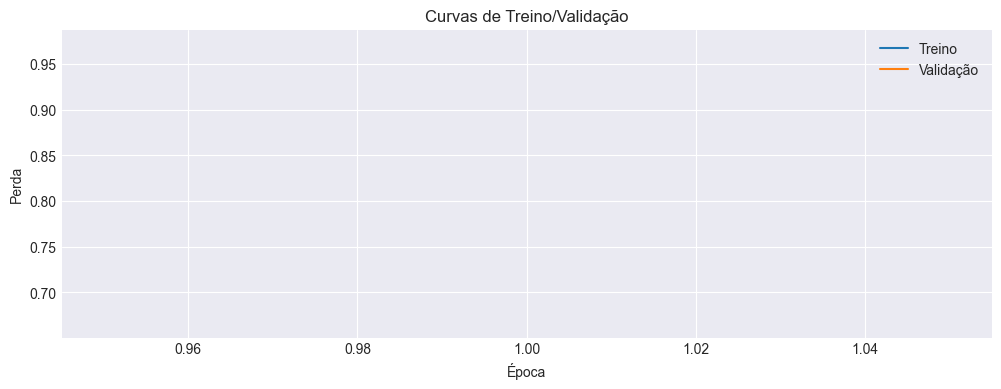

Época 1: Melhor modelo salvo com perda de validação 0.6658
Época 1/100 | Treino Loss: 0.9725 | Val Loss: 0.6658 | LR: 0.001000
Época 2/100 | Batch 10/101 | Loss: 0.6308
Época 2/100 | Batch 20/101 | Loss: 0.5490
Época 2/100 | Batch 30/101 | Loss: 0.4812
Época 2/100 | Batch 40/101 | Loss: 0.5579
Época 2/100 | Batch 50/101 | Loss: 0.5067
Época 2/100 | Batch 60/101 | Loss: 0.4117
Época 2/100 | Batch 70/101 | Loss: 0.5423
Época 2/100 | Batch 80/101 | Loss: 0.4416
Época 2/100 | Batch 90/101 | Loss: 0.3503
Época 2/100 | Batch 100/101 | Loss: 0.3618
Época 2: Perda de validação não melhorou. Contador de paciência: 1/15
Época 2/100 | Treino Loss: 0.4854 | Val Loss: 1.6934 | LR: 0.001000
Época 3/100 | Batch 10/101 | Loss: 0.3523
Época 3/100 | Batch 20/101 | Loss: 0.3283
Época 3/100 | Batch 30/101 | Loss: 0.3622
Época 3/100 | Batch 40/101 | Loss: 0.2886
Época 3/100 | Batch 50/101 | Loss: 0.3972
Época 3/100 | Batch 60/101 | Loss: 0.3228
Época 3/100 | Batch 70/101 | Loss: 0.4332
Época 3/100 | Batch 

In [25]:
def train_model(model, train_loader, val_loader, optimizer, criterion, 
                device, epochs, scheduler=None, grad_clip=None, 
                early_stopping_patience=15):
    """
    Treina o modelo TCN.
    
    Args:
        model: Modelo TCN
        train_loader: DataLoader para dados de treino
        val_loader: DataLoader para dados de validação
        optimizer: Otimizador
        criterion: Função de perda
        device: Dispositivo (CPU/GPU)
        epochs: Número de épocas
        scheduler: Scheduler para ajuste da taxa de aprendizado
        grad_clip: Valor para clipping de gradiente
        early_stopping_patience: Paciência para early stopping
        
    Returns:
        Dict com histórico de treino
    """
    model = model.to(device)
    
    # Inicializar o Animator
    animator = Animator(
        xlabel='Época',
        ylabel='Perda',
        legend=['Treino', 'Validação'],
        title='Curvas de Treino/Validação'
    )
    
    # Histórico de treino
    history = {
        'train_loss': [],
        'val_loss': [],
        'lr': []
    }
    
    # Early stopping
    best_val_loss = float('inf')
    patience_counter = 0
    best_model_state = None
    
    for epoch in range(epochs):
        # Modo de treino
        model.train()
        train_loss = 0.0
        
        for batch_idx, (X_batch, y_batch) in enumerate(train_loader):
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            
            # Zera os gradientes
            optimizer.zero_grad()
            
            # Forward pass
            y_pred = model(X_batch)
            loss = criterion(y_pred, y_batch)
            
            # Backward pass
            loss.backward()
            
            # Clipping de gradiente (se especificado)
            if grad_clip is not None:
                torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
                
            # Atualiza os pesos
            optimizer.step()
            
            # Acumula a perda
            train_loss += loss.item()
            
            # Progresso
            if (batch_idx + 1) % 10 == 0:
                print(f'Época {epoch+1}/{epochs} | Batch {batch_idx+1}/{len(train_loader)} | '
                      f'Loss: {loss.item():.4f}')
        
        # Calcula a perda média de treino
        train_loss /= len(train_loader)
        history['train_loss'].append(train_loss)
        
        # Modo de avaliação
        model.eval()
        val_loss = 0.0
        
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                
                # Forward pass
                y_pred = model(X_batch)
                loss = criterion(y_pred, y_batch)
                
                # Acumula a perda
                val_loss += loss.item()
                
        # Calcula a perda média de validação
        val_loss /= len(val_loader)
        history['val_loss'].append(val_loss)
        
        # Atualiza a taxa de aprendizado (se scheduler especificado)
        if scheduler is not None:
            if isinstance(scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau):
                scheduler.step(val_loss)
            else:
                scheduler.step()
        
        # Armazena a taxa de aprendizado atual
        history['lr'].append(optimizer.param_groups[0]['lr'])
        
        # Atualiza o gráfico
        animator.add(epoch+1, [train_loss, val_loss])
        
        # Early stopping
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
            best_model_state = model.state_dict().copy()
            print(f'Época {epoch+1}: Melhor modelo salvo com perda de validação {val_loss:.4f}')
        else:
            patience_counter += 1
            print(f'Época {epoch+1}: Perda de validação não melhorou. Contador de paciência: {patience_counter}/{early_stopping_patience}')
            
        if patience_counter >= early_stopping_patience:
            print(f'Early stopping acionado após {epoch+1} épocas')
            break
            
        print(f'Época {epoch+1}/{epochs} | '
              f'Treino Loss: {train_loss:.4f} | '
              f'Val Loss: {val_loss:.4f} | '
              f'LR: {optimizer.param_groups[0]["lr"]:.6f}')
        
    # Carrega o melhor modelo
    if best_model_state is not None:
        model.load_state_dict(best_model_state)
        print(f'Melhor modelo carregado com perda de validação {best_val_loss:.4f}')
    
    return history, model

# Configuração do treinamento
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Usando dispositivo: {device}")

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=5
)
# scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
#     optimizer, mode='min', factor=0.5, patience=5, verbose=True
# )
# Treinamento do modelo
history, trained_model = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    criterion=criterion,
    device=device,
    epochs=100,  # Vamos definir um número alto, mas usar early stopping
    scheduler=scheduler,
    grad_clip=1.0,
    early_stopping_patience=15
)

# Salvar o modelo treinado
torch.save(trained_model.state_dict(), 'tcn_model.pth')

Métricas de avaliação no conjunto de teste:
MAE: 1696.3165
RMSE: 2014.3014
SMAPE: 55.3316


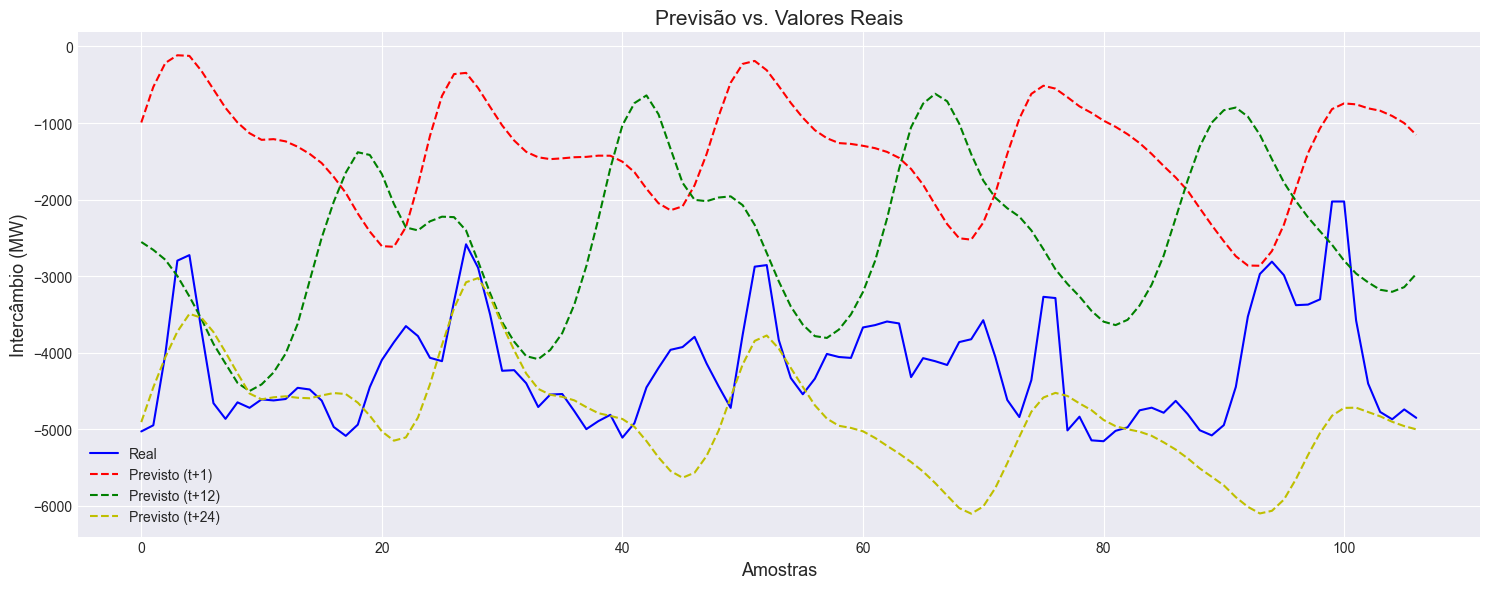

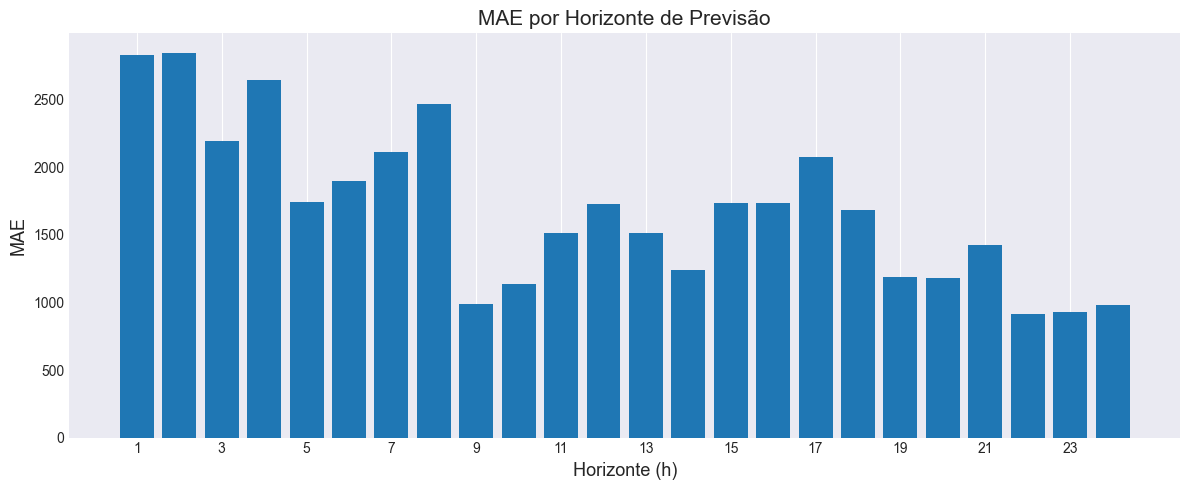

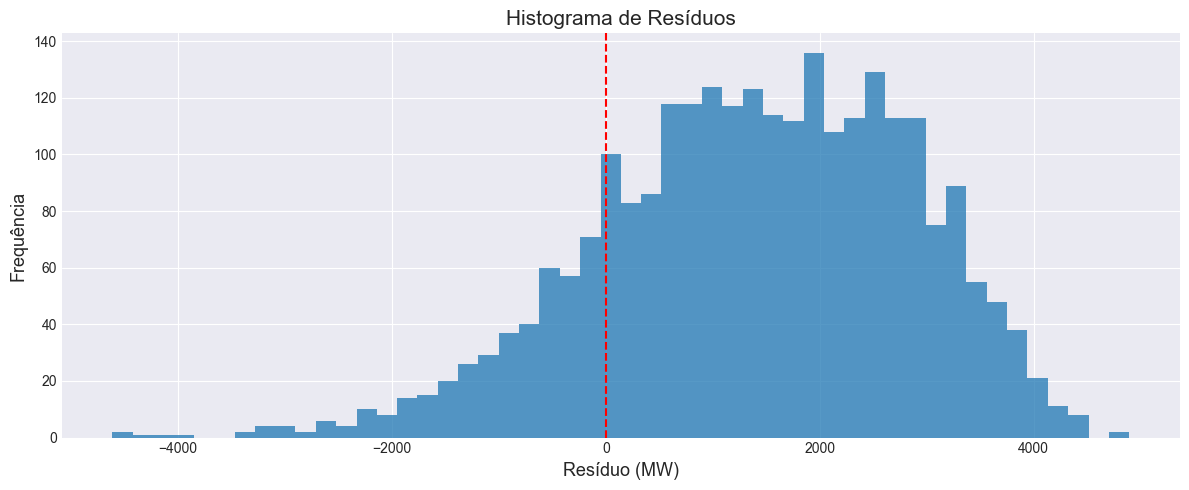

Estatísticas dos resíduos:
Média: 1390.7938
Desvio padrão: 1457.0872
Mínimo: -4613.6055
Máximo: 4894.6177

Comparação com baseline sazonal:
Métricas do modelo:
MAE: 1696.3165
RMSE: 2014.3014
SMAPE: 55.3316

Métricas da baseline:
MAE: 750.0563
RMSE: 976.6179
SMAPE: 19.3767


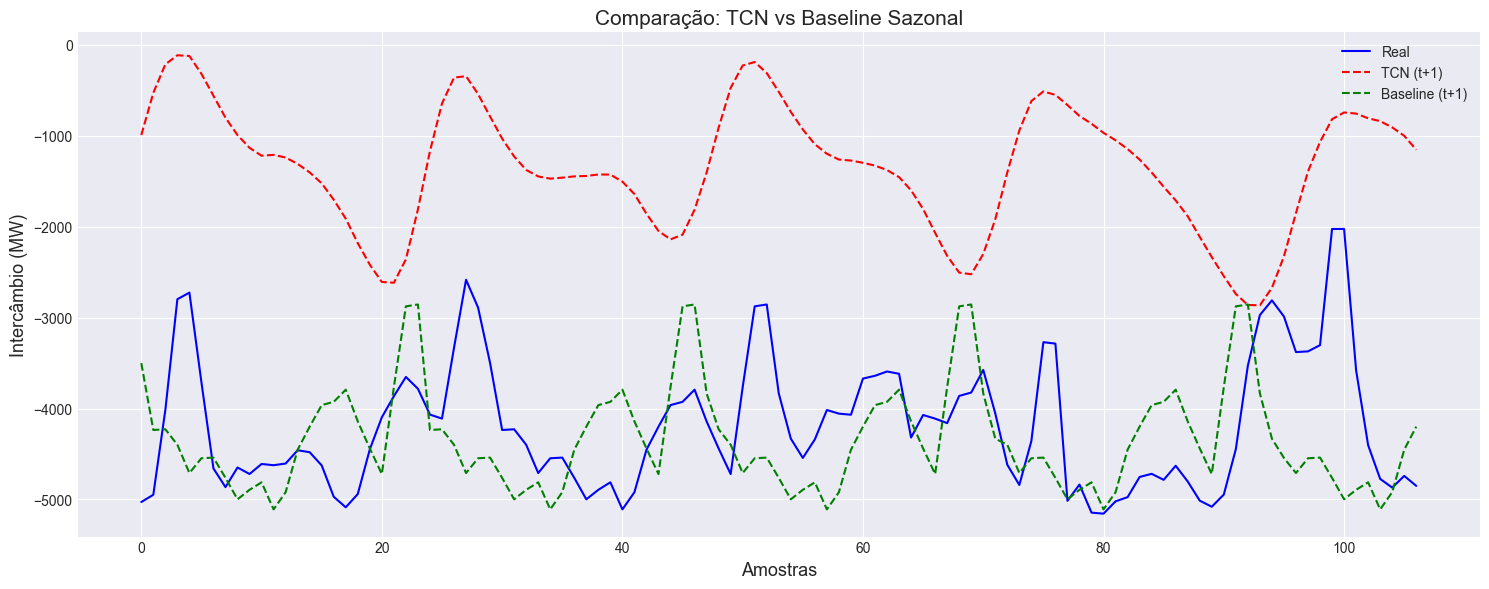


Melhoria percentual do modelo em relação à baseline:
MAE: -126.16%
RMSE: -106.25%
SMAPE: -185.56%


In [26]:
def predict(model, loader, device, inverse_scaler=None):
    """
    Faz previsões com o modelo.
    
    Args:
        model: Modelo treinado
        loader: DataLoader com dados para previsão
        device: Dispositivo (CPU/GPU)
        inverse_scaler: Scaler para inverter a normalização
        
    Returns:
        Arrays com previsões e valores reais
    """
    model.eval()
    y_pred_list = []
    y_true_list = []
    
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            
            # Forward pass
            y_pred = model(X_batch)
            
            # Mover para CPU e converter para numpy
            y_pred = y_pred.cpu().numpy()
            y_batch = y_batch.cpu().numpy()
            
            y_pred_list.append(y_pred)
            y_true_list.append(y_batch)
    
    # Concatenar resultados
    y_pred = np.vstack(y_pred_list)
    y_true = np.vstack(y_true_list)
    
    # Inverter a normalização se necessário
    if inverse_scaler is not None:
        y_pred_df = pd.DataFrame(y_pred, columns=[f'pred_{i}' for i in range(y_pred.shape[1])])
        y_true_df = pd.DataFrame(y_true, columns=[f'true_{i}' for i in range(y_true.shape[1])])
        
        y_pred = inverse_scaler.inverse_transform(y_pred_df).values
        y_true = inverse_scaler.inverse_transform(y_true_df).values
    
    return y_pred, y_true

# Fazer previsões no conjunto de teste
test_pred_scaled, test_true_scaled = predict(trained_model, test_loader, device)

# Criar DataFrames para inverter a transformação
test_pred_df = pd.DataFrame(test_pred_scaled, columns=[f'pred_{i}' for i in range(horizon)])
test_true_df = pd.DataFrame(test_true_scaled, columns=[f'true_{i}' for i in range(horizon)])

# Inverter a normalização
test_pred = y_scaler.inverse_transform(test_pred_df).values
test_true = y_scaler.inverse_transform(test_true_df).values

# Calcular métricas
metrics = calculate_metrics(test_true, test_pred)
print("Métricas de avaliação no conjunto de teste:")
for metric_name, metric_value in metrics.items():
    print(f"{metric_name.upper()}: {metric_value:.4f}")

# Visualizar os resultados
def plot_predictions(y_true, y_pred, start_idx=0, num_steps=168):
    """
    Plota as previsões versus os valores reais.
    
    Args:
        y_true: Array com valores reais
        y_pred: Array com valores previstos
        start_idx: Índice inicial para plotagem
        num_steps: Número de passos a serem plotados
    """
    plt.figure(figsize=(15, 6))
    
    # Seleciona um subconjunto dos dados para melhor visualização
    end_idx = min(start_idx + num_steps, len(y_true))
    x_values = np.arange(start_idx, end_idx)
    
    # Plot para o primeiro horizonte (t+1)
    plt.plot(x_values, y_true[start_idx:end_idx, 0], 'b-', label='Real')
    plt.plot(x_values, y_pred[start_idx:end_idx, 0], 'r--', label='Previsto (t+1)')
    
    # Plot para o horizonte médio (t+12)
    if horizon >= 12:
        plt.plot(x_values, y_pred[start_idx:end_idx, 11], 'g--', label='Previsto (t+12)')
    
    # Plot para o último horizonte (t+horizon)
    if horizon > 1:
        plt.plot(x_values, y_pred[start_idx:end_idx, -1], 'y--', label='Previsto (t+24)')
    
    plt.title('Previsão vs. Valores Reais', fontsize=15)
    plt.xlabel('Amostras', fontsize=13)
    plt.ylabel('Intercâmbio (MW)', fontsize=13)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# Plotar previsões
plot_predictions(test_true, test_pred, start_idx=0, num_steps=168)  # 7 dias

# Analisar erros por horizonte
def plot_error_by_horizon(y_true, y_pred):
    """
    Plota o erro (MAE) por horizonte de previsão.
    
    Args:
        y_true: Array com valores reais
        y_pred: Array com valores previstos
    """
    mae_by_horizon = []
    
    for h in range(horizon):
        mae = np.mean(np.abs(y_true[:, h] - y_pred[:, h]))
        mae_by_horizon.append(mae)
    
    plt.figure(figsize=(12, 5))
    plt.bar(range(1, horizon+1), mae_by_horizon)
    plt.title('MAE por Horizonte de Previsão', fontsize=15)
    plt.xlabel('Horizonte (h)', fontsize=13)
    plt.ylabel('MAE', fontsize=13)
    plt.grid(axis='y')
    plt.xticks(range(1, horizon+1, 2))
    plt.tight_layout()
    plt.show()

# Plotar erro por horizonte
plot_error_by_horizon(test_true, test_pred)

# Histograma de resíduos
def plot_residual_histogram(y_true, y_pred):
    """
    Plota o histograma dos resíduos.
    
    Args:
        y_true: Array com valores reais
        y_pred: Array com valores previstos
    """
    residuals = (y_pred - y_true).flatten()
    
    plt.figure(figsize=(12, 5))
    plt.hist(residuals, bins=50, alpha=0.75)
    plt.title('Histograma de Resíduos', fontsize=15)
    plt.xlabel('Resíduo (MW)', fontsize=13)
    plt.ylabel('Frequência', fontsize=13)
    plt.axvline(x=0, color='r', linestyle='--')
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    
    # Estatísticas básicas dos resíduos
    print("Estatísticas dos resíduos:")
    print(f"Média: {np.mean(residuals):.4f}")
    print(f"Desvio padrão: {np.std(residuals):.4f}")
    print(f"Mínimo: {np.min(residuals):.4f}")
    print(f"Máximo: {np.max(residuals):.4f}")

# Plotar histograma de resíduos
plot_residual_histogram(test_true, test_pred)

# Comparação com baseline
def compare_with_baseline(test_X, test_y, test_pred, window_size, horizon, seasonal_period=24):
    """
    Compara o modelo com uma baseline sazonal.
    
    Args:
        test_X: Features de teste
        test_y: Target de teste
        test_pred: Previsões do modelo
        window_size: Tamanho da janela
        horizon: Horizonte de previsão
        seasonal_period: Período sazonal (24 para diário, 168 para semanal)
    """
    # Obtemos os dados originais para criar a baseline
    original_y = test_y.flatten()
    
    # Inicializamos arrays para as previsões baseline
    baseline_predictions = []
    
    # Para cada amostra no conjunto de teste
    for i in range(len(test_y)):
        # Obtemos os últimos `window_size` pontos antes da previsão
        history = original_y[i:i+window_size]
        
        # Criamos a previsão baseline
        baseline_pred = baseline_seasonal_prediction(history, horizon, seasonal_period)
        baseline_predictions.append(baseline_pred)
    
    baseline_predictions = np.array(baseline_predictions)
    
    # Calculamos métricas para a baseline
    baseline_metrics = calculate_metrics(test_y, baseline_predictions)
    
    print("\nComparação com baseline sazonal:")
    print("Métricas do modelo:")
    for metric_name, metric_value in metrics.items():
        print(f"{metric_name.upper()}: {metric_value:.4f}")
    
    print("\nMétricas da baseline:")
    for metric_name, metric_value in baseline_metrics.items():
        print(f"{metric_name.upper()}: {metric_value:.4f}")
    
    # Plotamos a comparação
    plt.figure(figsize=(15, 6))
    start_idx = 0
    num_steps = 168  # 7 dias
    end_idx = min(start_idx + num_steps, len(test_y))
    x_values = np.arange(start_idx, end_idx)
    
    plt.plot(x_values, test_y[start_idx:end_idx, 0], 'b-', label='Real')
    plt.plot(x_values, test_pred[start_idx:end_idx, 0], 'r--', label='TCN (t+1)')
    plt.plot(x_values, baseline_predictions[start_idx:end_idx, 0], 'g--', label='Baseline (t+1)')
    
    plt.title('Comparação: TCN vs Baseline Sazonal', fontsize=15)
    plt.xlabel('Amostras', fontsize=13)
    plt.ylabel('Intercâmbio (MW)', fontsize=13)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    
    # Melhoria percentual em cada métrica
    print("\nMelhoria percentual do modelo em relação à baseline:")
    for metric_name in metrics:
        improvement = (baseline_metrics[metric_name] - metrics[metric_name]) / baseline_metrics[metric_name] * 100
        print(f"{metric_name.upper()}: {improvement:.2f}%")

# Comparar com baseline sazonal
compare_with_baseline(test_X, test_true, test_pred, window_size, horizon, seasonal_period=24)

## Conclusão

Neste notebook, implementamos uma Rede Neural Convolucional Temporal (TCN) para previsão de curvas de carga de energia elétrica. O modelo utiliza convoluções causais e dilatadas para capturar dependências temporais de longo prazo, mantendo a causalidade essencial para previsões de séries temporais.

A arquitetura TCN mostrou-se eficaz para esta tarefa, superando baselines sazonais. As convoluções dilatadas permitem um campo receptivo amplo sem a necessidade de camadas de pooling que perderiam informações temporais valiosas.

Aspectos importantes da implementação incluem:

1. Pré-processamento dos dados com normalização e features de calendário
2. Janelamento deslizante para criar amostras de treino/validação/teste
3. Blocos residuais com convoluções dilatadas, essenciais para a arquitetura TCN
4. Campo receptivo adequado para capturar a sazonalidade dos dados
5. Regularização via dropout e early stopping para evitar overfitting

Este modelo pode ser facilmente adaptado para outros tipos de séries temporais, ajustando parâmetros como o tamanho da janela, horizonte de previsão e arquitetura da rede.